# 1. Can the regional customer hotspots be found in the satellite archive?

**Scope:** 2019 and 2023, the customer's Jambi / South Sumatra locations only. The study rectangle is the bounding box of all customer locations in these two years, not the administrative province boundaries or confirmed concession boundaries. The regional map and per-`Region` table show exactly what is included. Counts for all Indonesia are input inventory only.

This notebook audits sources, time alignment, positional tolerance, ambiguous matches, repeated observations across providers, and unmatched records. It does **not** use `Status` to select matches or infer alert decisions. All customer rows count as list membership irrespective of fire verification.

**Result preview:** the named satellites are present, but source/product differences matter. Customer timestamps contain no minutes. UTC+7 with hour truncation has the strongest agreement among tested hour-bin models. At 500 m, 7,465/11,426 customer rows match in 2019 and 27,250/30,029 in 2023; many 2023 rows map to the same archive observation. A 500 m correspondence is approximate, so 100 m and broader sensitivities are reported.

Run all cells in order. This notebook and notebook 2 can each run independently. Computational helpers are in `hotspot_filter_analysis/analysis.py`; caches rebuild when source files or helper code change. Requirements are in `hotspot_filter_analysis/requirements.txt`.


## Findings for the supplied files — 11 September 2026

| Matching result | 2019 | 2023 |
|---|---:|---:|
| Customer rows | 11,426 | 30,029 |
| Same-satellite matches within 100 m | 3,631 (31.8%) | 22,817 (76.0%) |
| Same-satellite matches within 500 m | 7,465 (65.3%) | 27,250 (90.7%) |
| Unique archive observations represented by 500 m matches | 7,314 | 15,947 |
| Customer rows without a 500 m same-satellite match | 3,961 | 2,779 |

**Main interpretation:** 2023 can be compared reasonably well, but its raw spreadsheet count overstates the number of independent satellite detections. In 2019, incomplete correspondence is a major limitation: do not interpret an unmatched customer row as a rule failure.

**A concrete labeling problem:** 753 Aqua-labeled 2023 rows have strong Terra matches instead. **A concrete time-format problem:** the workbook has only whole hours, consistent with truncation after UTC+7 conversion. These need to be handled before interpreting filtering differences.

Narrative findings describe this input snapshot. If you replace inputs, the code rebuilds calculations, but review these written interpretations against the new results.


In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/customer/hotspot_master_2019_2023_2025_2026.xlsx').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook from the repository or one of its subdirectories.')
HELPERS = ROOT / 'notebooks/hotspot_filter_analysis'
sys.path.insert(0, str(HELPERS))
import importlib, analysis
importlib.reload(analysis)
from analysis import *
OUT = ROOT / 'notebooks/outputs/hotspot_filter_analysis'
OUT.mkdir(parents=True, exist_ok=True)
RECOMPUTE = False  # True forces reconstruction of intermediate calculations.
customer, satellite, inventory = load_inputs(ROOT)
input_fingerprint = hashlib.sha256((
    inventory[['file','sha256']].to_json() +
    hashlib.sha256((ROOT / 'data/customer/hotspot_master_2019_2023_2025_2026.xlsx').read_bytes()).hexdigest() +
    hashlib.sha256((HELPERS / 'analysis.py').read_bytes()).hexdigest()
).encode()).hexdigest()
print(f'Loaded {len(customer):,} customer records and {len(satellite):,} archive detections.')
print('Run cells from top to bottom: Kernel > Restart Kernel and Run All Cells.')


Loaded 41,455 customer records and 1,521,257 archive detections.
Run cells from top to bottom: Kernel > Restart Kernel and Run All Cells.


## Input and regional audit

`N` = SNPP, `N20` = NOAA20 (JPSS-1), and MODIS is carried by Aqua and Terra. `Sumber` identifies the data provider, not a fifth satellite. Missing satellite names are retained as `Unknown`; they are not silently assigned. Source rows with identifier-like provider values are exported for review. Exact duplicate archive rows are removed before any neighborhood calculation.


In [2]:
display(inventory.drop(columns='sha256'))
bounds = customer_bbox(customer)
print('Regional bounding box (west, south, east, north):', bounds)
regions = customer.groupby('Region').agg(rows=('customer_id','size'), west=('Longitude','min'),
    east=('Longitude','max'), south=('Latitude','min'), north=('Latitude','max'))
display(regions)
source_counts = customer.groupby(['year','Sumber','Satellite'],dropna=False).size().rename('customer_rows').reset_index()
display(source_counts)
print('Customer minute values:', sorted(customer.Tgl_Hotspot.dt.minute.unique()))
assert customer.Tgl_Hotspot.dt.minute.eq(0).all(), 'Revisit time-bin matching if minute precision changes.'
anomalies = customer.loc[customer.Satellite.eq('Unknown') | ~customer.Sumber.isin(['NASA','LAPAN','ASMC'])]
display(anomalies.head(10))
regional_counts = satellite.loc[within_bbox(satellite,bounds)].groupby(['year','satellite_name']).size().rename('archive_rows')
display(regional_counts)
inventory.to_csv(OUT / 'input_inventory.csv', index=False)
regions.to_csv(OUT / 'customer_region_bounds.csv')
source_counts.to_csv(OUT / 'customer_sources.csv', index=False)
anomalies.to_csv(OUT / 'source_anomalies.csv', index=False)
regional_counts.to_csv(OUT / 'regional_archive_counts.csv')


,file,year,rows,duplicates_removed,satellites,first_utc,last_utc,versions
0,data/satelites/modis/2019/modis_2019_Indonesia...,2019,90475,0,"Aqua,Terra",2019-01-01 01:19:00,2019-12-31 17:00:00,6.03
1,data/satelites/modis/2023/modis_2023_Indonesia...,2023,52156,0,"Aqua,Terra",2023-01-01 06:40:00,2023-12-31 18:14:00,61.03
2,data/satelites/viirs-jpss1/2019/viirs-jpss1_20...,2019,437645,0,NOAA20,2019-01-01 05:01:00,2019-12-31 18:59:00,2
3,data/satelites/viirs-jpss1/2023/viirs-jpss1_20...,2023,250312,0,NOAA20,2023-01-01 05:08:00,2023-12-31 17:27:00,2
4,data/satelites/viirs-snpp/2019/viirs-snpp_2019...,2019,437281,0,SNPP,2019-01-01 04:10:00,2019-12-31 18:10:00,2
5,data/satelites/viirs-snpp/2023/viirs-snpp_2023...,2023,253388,0,SNPP,2023-01-01 05:59:00,2023-12-31 18:17:00,2


Regional bounding box (west, south, east, north): (np.float64(101.82584), np.float64(-4.0146), np.float64(106.03881836), np.float64(-0.73477989))


,rows,west,east,south,north
Region,,,,,
JAMBI SMF,4089,101.82584,103.951000,-1.585088,-0.734780
SUMSEL,32257,105.17325,106.038818,-4.014600,-2.404260
SUMSEL MUBA,5109,102.98499,104.545921,-2.567890,-1.664889


,year,Sumber,Satellite,customer_rows
0,2019,0-3082272,Unknown,1
1,2019,0-3083220,Unknown,2
2,2019,0-3085969,Unknown,1
3,2019,ASMC,NOAA20,2407
4,2019,ASMC,Unknown,2
5,2019,LAPAN,Aqua,3558
6,2019,LAPAN,SNPP,3604
7,2019,LAPAN,Terra,1811
8,2019,LAPAN,Unknown,40
9,2023,LAPAN,Aqua,562


Customer minute values: [np.int32(0)]


,Longitude,Latitude,Tgl_Hotspot,Sumber,Satellite,Status,Region,excel_row,sheet,customer_id,year
100,103.102623,-0.905719,2019-05-26 10:00:00,LAPAN,Unknown,Verified No fire,JAMBI SMF,102,2019,2019:102,2019
104,103.099831,-0.904422,2019-05-26 13:00:00,LAPAN,Unknown,Verified No fire,JAMBI SMF,106,2019,2019:106,2019
107,103.240860,-1.059588,2019-06-04 10:00:00,LAPAN,Unknown,Verified No fire,JAMBI SMF,109,2019,2019:109,2019
110,103.473282,-1.060196,2019-06-20 13:00:00,LAPAN,Unknown,Verified No fire,JAMBI SMF,112,2019,2019:112,2019
116,103.108162,-0.906694,2019-06-27 10:00:00,LAPAN,Unknown,Verified No fire,JAMBI SMF,118,2019,2019:118,2019
118,103.106102,-0.909417,2019-06-27 13:00:00,LAPAN,Unknown,Verified No fire,JAMBI SMF,120,2019,2019:120,2019
119,103.482750,-1.086895,2019-06-27 13:00:00,LAPAN,Unknown,Verified No fire,JAMBI SMF,121,2019,2019:121,2019
128,105.442444,-3.009868,2019-07-01 13:00:00,LAPAN,Unknown,Verified No fire,SUMSEL,130,2019,2019:130,2019
129,103.109680,-0.962162,2019-07-04 10:00:00,LAPAN,Unknown,Verified No fire,JAMBI SMF,131,2019,2019:131,2019
131,105.489937,-2.922971,2019-07-04 10:00:00,LAPAN,Unknown,Verified No fire,SUMSEL,133,2019,2019:133,2019


year  satellite_name
2019  Aqua              10966
      NOAA20            86947
      SNPP              87104
      Terra              7732
2023  Aqua               4688
      NOAA20            33050
      SNPP              34333
      Terra              2711
Name: archive_rows, dtype: int64

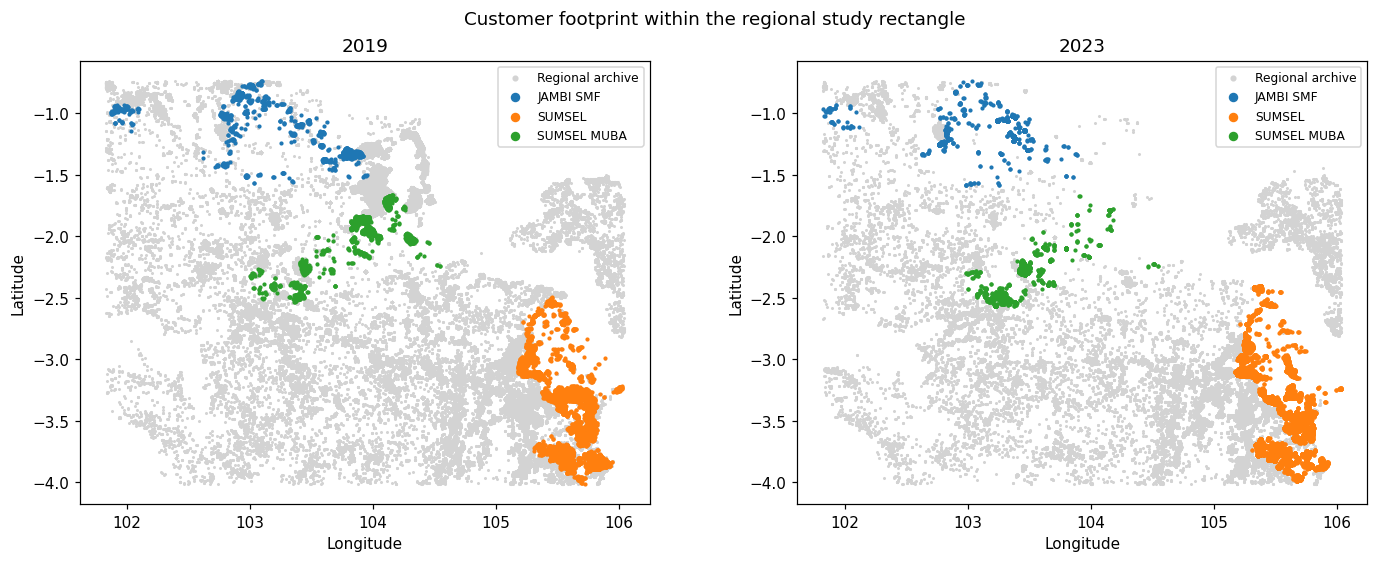

In [3]:
fig, axes = plt.subplots(1,2,figsize=(13,5),constrained_layout=True)
for ax,year in zip(axes,YEARS):
    s = satellite.loc[satellite.year.eq(year) & within_bbox(satellite,bounds)]
    ax.scatter(s.longitude,s.latitude,s=1,c='lightgray',rasterized=True,label='Regional archive')
    for name,c in customer.loc[customer.year.eq(year)].groupby('Region'):
        ax.scatter(c.Longitude,c.Latitude,s=3,label=name,rasterized=True)
    ax.set(title=str(year),xlabel='Longitude',ylabel='Latitude',aspect='equal')
    ax.legend(markerscale=3,fontsize=8)
fig.suptitle('Customer footprint within the regional study rectangle')
fig.savefig(OUT / 'regional_footprint.png',dpi=160)
plt.show()


## Match without assuming a timezone

Generate all candidates within 2 km on the same or adjacent UTC dates. Compare integer UTC offsets −12 through +14 using three timestamp models: local-hour truncation, nearest-hour rounding (±30 minutes), and a permissive ±60-minute model. Diagnose offsets with a 100 m spatial tolerance so unrelated nearby pixels contribute less.

The principal alignment is **customer timestamp = floor(UTC + 7 hours, to the hour)**. For example, 06:43 UTC becomes 13:00 in the workbook. This inference does not recover minutes for unmatched records. The broader ±60-minute model can yield more matches simply because it permits a two-hour interval; compare like-width models before interpreting the result.


In [4]:
candidate_path = OUT / 'matching_candidates.pkl'
match_manifest = OUT / 'matching_cache.json'
cache_ok = (candidate_path.exists() and match_manifest.exists()
            and json.loads(match_manifest.read_text()).get('fingerprint') == input_fingerprint)
if RECOMPUTE or not cache_ok:
    pairs = match_candidates(customer, satellite, radius_km=2)
    pairs.to_pickle(candidate_path)
    match_manifest.write_text(json.dumps({'fingerprint':input_fingerprint, 'radius_km':2}, indent=2))
else:
    pairs = pd.read_pickle(candidate_path)  # Only this locally generated, fingerprinted cache.
matches = select_matches(pairs, radius_km=0.5, offset=7, mode='floor')
strict_matches = select_matches(pairs, radius_km=0.1, offset=7, mode='floor')
print(f'{len(pairs):,} spatial candidates; {len(matches):,} customer rows matched within 500 m.')


1,887,420 spatial candidates; 34,715 customer rows matched within 500 m.


,year,mode,utc_offset_hours,matched,customer_rows,coverage
38,2019,floor,7,3631,11426,0.317784
90,2019,nearest,6,2699,11426,0.236216
144,2019,plusminus60,6,4005,11426,0.350516
39,2023,floor,7,22817,30029,0.759832
91,2023,nearest,6,13598,30029,0.452829
145,2023,plusminus60,6,23540,30029,0.783909


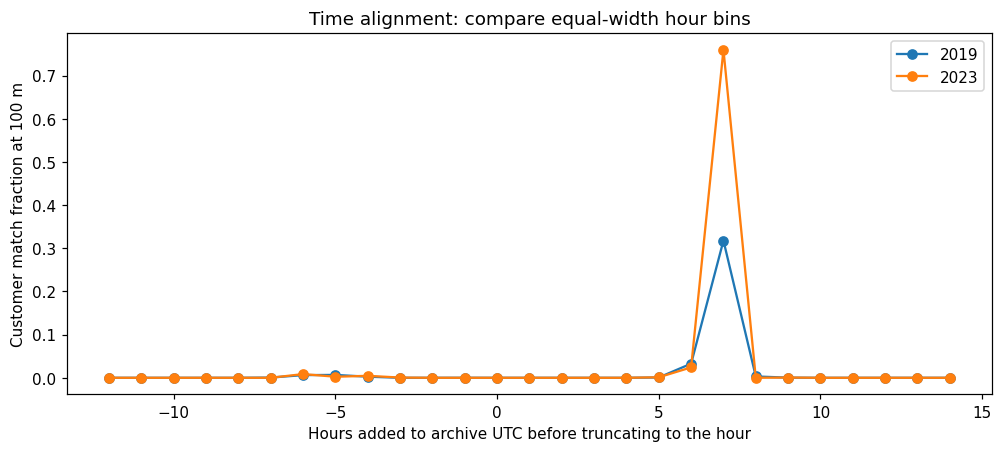

In [5]:
alignment = match_audit(customer,pairs)
display(alignment.sort_values('matched',ascending=False).groupby(['year','mode']).head(1).sort_values(['year','mode']))
fig,ax = plt.subplots(figsize=(9,4),constrained_layout=True)
for year in YEARS:
    a=alignment.loc[alignment.year.eq(year)&alignment['mode'].eq('floor')]
    ax.plot(a.utc_offset_hours,a.coverage,marker='o',label=str(year))
ax.set(xlabel='Hours added to archive UTC before truncating to the hour',ylabel='Customer match fraction at 100 m',
       title='Time alignment: compare equal-width hour bins')
ax.legend();fig.savefig(OUT / 'time_alignment.png',dpi=160);plt.show()
alignment.to_csv(OUT / 'time_alignment.csv',index=False)


**Finding — time alignment.** With equal-width hour bins and 100 m matching, UTC+7 produces 3,631 matches in 2019 and 22,817 in 2023; UTC+6 produces only 374 and 725. This is strong evidence for the UTC+7 hour-truncation model. A wider ±60-minute model can match more rows but allows twice the time span, so its higher count does not establish a different timezone. The missing minutes mean unmatched customer rows cannot independently establish a 30-minute temporal sequence.


## Spatial tolerance and matching ambiguity

The main comparison permits 500 m and requires the named satellite. This accommodates some geolocation/product differences, but can pick an adjacent pixel. The 100 m subset is more conservative, especially when it has only one candidate. The nearest spatial candidate wins; time residual and archive ID break ties. Exported `candidate_count` reports all qualifying candidates. This is a many-to-one correspondence: multiple provider records can refer to one archive detection. Satellite-level list comparisons count that detection once.

The 1 km / 2 km matching tolerances below are sensitivity diagnostics, **not** the alert neighborhood radius. Another satellite at the same place and time is only a possible label/source issue; it does not prove that satellite supplied the customer record.


In [6]:
sensitivity_rows=[]
for radius in [.025,.1,.25,.5,1,2]:
    for mode in ['floor','nearest','plusminus60']:
        m=select_matches(pairs,radius,7,mode)
        for year in YEARS:
            my=m.loc[customer.loc[m.customer_index,'year'].to_numpy()==year]
            n=int(customer.year.eq(year).sum())
            sensitivity_rows.append(dict(year=year,radius_m=radius*1000,time_model=mode,
                customer_rows=n,matched_rows=len(my),match_fraction=len(my)/n,
                unique_archive_detections=my.sid.nunique(),ambiguous_rows=int(my.candidate_count.gt(1).sum())))
sensitivity=pd.DataFrame(sensitivity_rows)
display(sensitivity.loc[sensitivity.time_model.eq('floor')].round(4))
sensitivity.to_csv(OUT / 'match_sensitivity.csv',index=False)
match_rows=customer.merge(matches,left_index=True,right_on='customer_index',how='left')
match_rows['matched']=match_rows.sid.notna()
by_source=match_rows.groupby(['year','Sumber','Satellite']).agg(customer_rows=('customer_id','size'),
    matched_rows=('matched','sum'),coverage=('matched','mean'),unique_archive_detections=('sid','nunique'))
display(by_source.round(4))
by_source.to_csv(OUT / 'match_coverage_by_source.csv')
match_rows.to_csv(OUT / 'customer_match_audit.csv',index=False)
match_rows.loc[~match_rows.matched].to_csv(OUT / 'unmatched_customer_rows.csv',index=False)
matches.to_csv(OUT / 'matches_500m.csv',index=False)
strict_matches.to_csv(OUT / 'matches_100m.csv',index=False)


,year,radius_m,time_model,customer_rows,matched_rows,match_fraction,unique_archive_detections,ambiguous_rows
0,2019,25.0,floor,11426,2049,0.1793,2049,0
1,2023,25.0,floor,30029,14371,0.4786,14237,24
6,2019,100.0,floor,11426,3631,0.3178,3628,0
7,2023,100.0,floor,30029,22817,0.7598,15360,438
12,2019,250.0,floor,11426,4876,0.4267,4827,71
13,2023,250.0,floor,30029,26834,0.8936,15832,2956
18,2019,500.0,floor,11426,7465,0.6533,7314,2473
19,2023,500.0,floor,30029,27250,0.9075,15947,16903
24,2019,1000.0,floor,11426,7890,0.6905,7521,4165
25,2023,1000.0,floor,30029,27326,0.9100,15978,21002


customer_rows  ...  unique_archive_detections
year Sumber    Satellite                 ...                           
2019 0-3082272 Unknown                1  ...                          0
     0-3083220 Unknown                2  ...                          0
     0-3085969 Unknown                1  ...                          0
     ASMC      NOAA20              2407  ...                       1633
               Unknown                2  ...                          0
     LAPAN     Aqua                3558  ...                       2143
               SNPP                3604  ...                       2046
               Terra               1811  ...                       1492
               Unknown               40  ...                          0
2023 LAPAN     Aqua                 562  ...                        219
               NOAA20              6435  ...                       5224
               SNPP                6227  ...                       5567
     NASA      Aqua                1646  ...                        962
               NOAA20              7803  ...                       7609
               SNPP                7356  ...                       7326

[15 rows x 4 columns]

**Finding — the mismatch is concentrated in specific sources.** At 100 m, 2023 NASA/SNPP matches 7,334/7,356 rows (99.7%) and NASA/NOAA20 matches 7,610/7,803 (97.5%). In contrast, 2019 LAPAN/SNPP matches just 48/3,604 (1.3%), and ASMC/NOAA20 matches 18/2,407 (0.7%). At 500 m those two 2019 groups improve to 57.3% and 69.3%. This pattern is compatible with an original-product or positional difference, rather than a single universal matching tolerance. The original 2019 feeds are needed to distinguish 375 m versus 750 m products, processing differences, and other causes; this analysis does not establish a resolution change.


In [7]:
# Diagnose repeated mappings without declaring every 500 m collision a duplicate.
repeats=match_rows.loc[match_rows.matched].groupby(['year','sid']).agg(
    customer_rows=('customer_id','size'),providers=('Sumber',lambda x: ', '.join(sorted(set(x)))),
    distinct_providers=('Sumber','nunique'),max_distance_km=('distance_km','max'))
repeats=repeats.loc[repeats.customer_rows.gt(1)]
display(repeats.groupby('year').agg(shared_archive_detections=('customer_rows','size'),
    excess_customer_rows=('customer_rows',lambda x:int((x-1).sum())),
    shared_across_providers=('distinct_providers',lambda x:int((x>1).sum()))))
repeats.to_csv(OUT / 'repeated_archive_mappings.csv')

# Loose rescue diagnostics for rows unmatched by the primary same-satellite protocol.
strict2=select_matches(pairs,2,7,'floor')
anysat=select_matches(pairs,.5,7,'floor',any_satellite=True)
wide=select_matches(pairs,.5,7,'plusminus60')
diag=customer[['customer_id','year','Sumber','Satellite']].copy()
diag['primary_500m']=diag.index.isin(matches.customer_index)
diag['same_sat_2km']=diag.index.isin(strict2.customer_index)
diag['any_sat_500m']=diag.index.isin(anysat.customer_index)
diag['same_sat_wide_time_500m']=diag.index.isin(wide.customer_index)
diag=diag.loc[~diag.primary_500m]
display(diag.groupby(['year','Sumber','Satellite']).agg(unmatched=('customer_id','size'),
    same_sat_2km=('same_sat_2km','sum'),any_sat_500m=('any_sat_500m','sum'),wide_time_500m=('same_sat_wide_time_500m','sum')))
diag.to_csv(OUT / 'unmatched_rescue_diagnostics.csv',index=False)
possible_sources=customer.loc[customer.index.isin(anysat.customer_index)&~customer.index.isin(matches.customer_index)].merge(
    anysat,left_index=True,right_on='customer_index').merge(satellite[['sid','satellite_name','utc']],on='sid')
possible_sources.to_csv(OUT / 'alternative_satellite_candidates.csv',index=False)

# Strong label-disagreement evidence: no original-satellite match at 500 m,
# exactly one candidate among ALL satellites at 100 m, known original satellite.
rescued = select_matches(pairs,.1,7,'floor',any_satellite=True)
rescued = rescued.loc[~rescued.customer_index.isin(matches.customer_index) &
    ~rescued.same_satellite & ~rescued.unknown_satellite & rescued.candidate_count.eq(1)]
label_disagreements = customer.merge(rescued,left_index=True,right_on='customer_index').merge(
    satellite[['sid','satellite_name','utc']],on='sid')
label_summary = label_disagreements.groupby(['year','Sumber','Satellite','satellite_name']).agg(
    rows=('customer_id','size'),median_distance_m=('distance_km',lambda x:x.median()*1000))
print('Likely satellite-label disagreements, retained only as a sensitivity:')
display(label_summary.round(2))
label_disagreements.to_csv(OUT/'strong_satellite_label_disagreements.csv',index=False)
label_summary.to_csv(OUT/'satellite_label_disagreement_summary.csv')


,shared_archive_detections,excess_customer_rows,shared_across_providers
year,,,
2019,151,151,0
2023,10984,11303,10960


unmatched  same_sat_2km  any_sat_500m  wide_time_500m
year Sumber    Satellite                                                       
2019 0-3082272 Unknown            1             0             0               0
     0-3083220 Unknown            2             0             0               0
     0-3085969 Unknown            1             0             0               0
     ASMC      NOAA20           740           254            86              31
               Unknown            2             0             0               0
     LAPAN     Aqua            1318           215           891              94
               SNPP            1538           130          1093             299
               Terra            319            58            66              16
               Unknown           40             0            35               0
2023 LAPAN     Aqua             343            34           217              14
               NOAA20          1072            11           116               4
               SNPP             484             7            28               8
     NASA      Aqua             681            39           598              44
               NOAA20           185             2            20               4
               SNPP              14             0             1               9

Likely satellite-label disagreements, retained only as a sensitivity:


rows  median_distance_m
year Sumber Satellite satellite_name                         
2019 ASMC   NOAA20    Aqua               2              53.83
                      SNPP               1              51.89
     LAPAN  Aqua      NOAA20             9              52.22
                      SNPP              18              76.17
            SNPP      Aqua               5              68.59
                      NOAA20            15              61.69
            Terra     Aqua               1              92.78
                      SNPP               2              37.59
2023 LAPAN  Aqua      SNPP               1              98.37
                      Terra            194              25.92
            NOAA20    SNPP              10              62.13
            SNPP      NOAA20             3              56.03
     NASA   Aqua      SNPP               2              49.73
                      Terra            559               4.45

**Finding — provider overlap and satellite labels both matter.** In 2023, 27,250 matched customer records map to only 15,947 distinct archive detections. Of 10,984 archive detections receiving multiple customer matches, 10,960 receive records from different providers. This is strong evidence that NASA/LAPAN overlap contributes substantially to the list size, although broad-radius collisions can also combine adjacent pixels.

For the source-label issue, 559 NASA and 194 LAPAN records labeled Aqua instead match Terra within 100 m, uniquely among all satellites, with no Aqua match within 500 m. These 753 records are likely mislabeled. Wider, several-hundred-metre cross-satellite alternatives are much weaker evidence, especially for the 2019 VIIRS records; they are exported but not automatically treated as corrections.


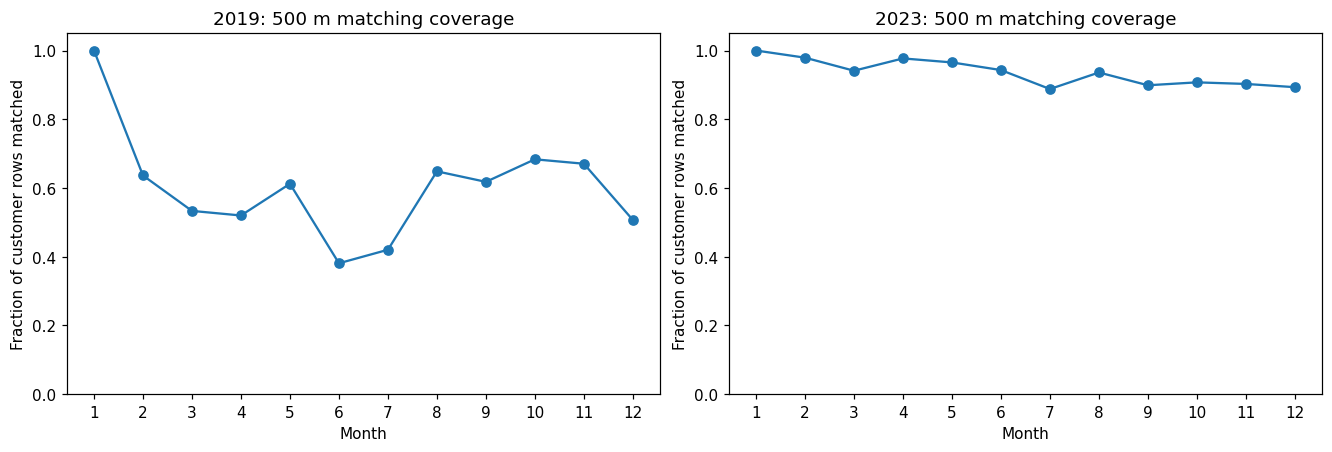

Passed: midnight, chains, self-exclusion, spatial/time boundaries, simultaneous/prior/cross-satellite, matching hour bins, and brute-force neighbor comparisons.


In [8]:
fig,axes=plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
for ax,year in zip(axes,YEARS):
    d=match_rows.loc[match_rows.year.eq(year)].copy()
    d['month']=d.Tgl_Hotspot.dt.month
    monthly=d.groupby('month').matched.agg(['size','mean'])
    ax.plot(monthly.index,monthly['mean'],marker='o')
    ax.set(title=f'{year}: 500 m matching coverage',xlabel='Month',ylabel='Fraction of customer rows matched',ylim=(0,1.05),xticks=range(1,13))
fig.savefig(OUT / 'monthly_match_coverage.png',dpi=160);plt.show()
print(synthetic_tests())
assert matches.customer_index.is_unique
assert matches.distance_km.le(.5).all() and matches.same_satellite.all()
assert strict_matches.customer_index.isin(matches.customer_index).all()
metadata={'fingerprint':input_fingerprint,'workbook_sha256':hashlib.sha256((ROOT/'data/customer/hotspot_master_2019_2023_2025_2026.xlsx').read_bytes()).hexdigest(),
    'region_bbox':list(bounds),'matching_radius_km':.5,'strict_radius_km':.1,'utc_offset':7,'time_model':'floor',
    'source_inventory':'input_inventory.csv','assumption':'Customer list membership is not an observed alert flag.'}
(OUT/'analysis_provenance.json').write_text(json.dumps(metadata,indent=2)+'\n')


## What matching establishes

**753 records labeled Aqua in 2023 instead have a unique Terra candidate within 100 m and the local-hour window, with no Aqua candidate within 500 m.** This is strong evidence of satellite mislabeling, especially the NASA records whose median alternative distance is only a few metres. The original workbook is unchanged; notebook 2 reports an explicit correction sensitivity. Thus the absence of a Terra label in 2023 is not evidence that Terra was unused.

All four named satellites are supplied. **46 customer rows in 2019 have no satellite name**, so their origin is unresolved. Matching quality is source-dependent: the 2023 NASA VIIRS records match extremely well even at 100 m, while 2019 ASMC/NOAA20 and LAPAN/SNPP match poorly at that tolerance and much better at 500 m. This is consistent with differences in original processing, geolocation, or product resolution; these files cannot determine which explanation is correct. NRT versus later standard archives and missing original provider feeds remain material limitations.

Thousands of 2023 NASA/LAPAN records correspond to shared archive detections; comparing the raw spreadsheet count directly to an archive count exaggerates disagreement. Broad-radius collisions can also merge adjacent pixels, which is why the stricter sensitivity remains important.

Proceed to notebook 2 for the actual spatial/temporal rule tests. Matching failure is kept separate from rule failure throughout.


### Sources and interpretation

- [NASA FIRMS API tutorial](https://firms.modaps.eosdis.nasa.gov/content/academy/data_api/firms_api_use.html): archive/SP versus NRT products and satellite identifiers.
- [NASA GIBS metadata documentation](https://nasa-gibs.github.io/gibs-api-docs/python-usage/): acquisition time is UTC.
- [NASA FIRMS workshop Q&A](https://appliedsciences.nasa.gov/sites/default/files/2025-05/Part%203%20FIRMS%202025%20Q%26A%20Session.docx.pdf): NRT/standard geolocation can differ, particularly for Aqua. A mismatch is not proof of a missing satellite.
- [NASA VIIRS fire validation](https://viirsland.gsfc.nasa.gov/Val/Fire_Val.html): distinct 375 m and 750 m fire products exist. The supplied VIIRS files are 375 m-format products; the workbook does not identify the original product resolution. A different product is a hypothesis, not an established explanation for 2019.
- [ASMC hotspot map](https://asmc.asean.org/asmc-hotspot/): ASMC is a hotspot provider and distributes NOAA-20 coordinates. Provider names must not be treated as satellite names.

Sources checked 2026-09-11. Input file checksums and product versions are exported by this notebook. No customer data are sent to web services.
